# **Prequisites**


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Importings**

## Libraries

In [2]:
import pandas as pd
import numpy as np

from imblearn.over_sampling import SMOTE

import tensorflow as tf

from tensorflow.keras.layers import Dense, Input, Lambda, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras import optimizers
from tensorflow.keras.utils import plot_model
from tensorflow.keras import backend as K
from tensorflow.keras import regularizers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelBinarizer, LabelEncoder

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10,5)

## Dataset

In [3]:
base_dir = '/content/drive/My Drive/power_transformer_fault_diagnosis/datasets/'
df = pd.read_csv(base_dir + 'Kaggle Transformer Dataset.csv')
df

,Hydrogen,Oxigen,Nitrogen,Methane,CO,CO2,Ethylene,Ethane,Acethylene,DBDS,Power factor,Interfacial V,Dielectric rigidity,Water content,Health index,Life expectation
0,2845,5860,27842,7406,32,1344,16684,5467,7,19.0,1.00,45,55,0,95.2,19.0
1,12886,61,25041,877,83,864,4,305,0,45.0,1.00,45,55,0,85.5,19.0
2,2820,16400,56300,144,257,1080,206,11,2190,1.0,1.00,39,52,11,85.3,19.0
3,1099,70,37520,545,184,1402,6,230,0,87.0,4.58,33,49,5,85.3,6.0
4,3210,3570,47900,160,360,2130,4,43,4,1.0,0.77,44,55,3,85.2,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
465,15,227,52900,3,60,853,3,84,0,0.0,1.00,32,56,28,13.4,51.0
466,15,334,47100,3,64,622,3,108,0,0.0,1.00,32,55,12,13.4,51.0
467,15,1280,35000,2,675,2530,0,0,0,5.0,0.30,45,58,8,13.4,6.5
468,15,169,50600,5,77,532,0,72,0,0.0,1.21,33,54,11,13.4,51.0


# **Peseudo-Labeling using Duval Triangle**

In [4]:
def duval_triangle(ch4_relative, c2h4_relative, c2h2_relative):
  
  if ch4_relative >= 98: status = 'PD'
  elif ch4_relative < 98 and c2h4_relative < 20 and c2h2_relative < 4: status = 'T1'
  elif 50 > c2h4_relative >= 20 and c2h2_relative < 4: status = 'T2'
  elif c2h4_relative >= 50 and c2h2_relative < 15: status = 'T3'
  elif c2h4_relative < 50 and 13 > c2h2_relative >= 4: status = 'DT'
  elif 40 <= c2h4_relative < 50 and 29 > c2h2_relative >= 13: status = 'DT'
  elif 50 <= c2h4_relative and 29 > c2h2_relative >= 15: status = 'DT'
  elif 23 < c2h4_relative and c2h2_relative >= 13: status = 'D1'
  elif 23 <= c2h4_relative and c2h2_relative >= 29: status = 'D2'
  elif 23 <= c2h4_relative < 40 and 29 > c2h2_relative >= 13: status = 'D2'
  else: status = 'other'

  return status

In [5]:
duval_state = []

for index, row in df.iterrows():

  ch4_relative = row['Methane']/(row['Methane'] + row['Ethylene'] + row['Acethylene']) * 100
  c2h4_relative = row['Ethylene']/(row['Methane'] + row['Ethylene'] + row['Acethylene']) * 100
  c2h2_relative = row['Acethylene']/(row['Methane'] + row['Ethylene'] + row['Acethylene']) * 100

  duval_state.append(duval_triangle(ch4_relative, c2h4_relative, c2h2_relative))

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:5: RuntimeWarning: invalid value encountered in double_scalars
  """
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in double_scalars
  
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:7: RuntimeWarning: invalid value encountered in double_scalars
  import sys


In [6]:
df['duval_state'] = duval_state
df

,Hydrogen,Oxigen,Nitrogen,Methane,CO,CO2,Ethylene,Ethane,Acethylene,DBDS,Power factor,Interfacial V,Dielectric rigidity,Water content,Health index,Life expectation,duval_state
0,2845,5860,27842,7406,32,1344,16684,5467,7,19.0,1.00,45,55,0,95.2,19.0,T3
1,12886,61,25041,877,83,864,4,305,0,45.0,1.00,45,55,0,85.5,19.0,PD
2,2820,16400,56300,144,257,1080,206,11,2190,1.0,1.00,39,52,11,85.3,19.0,other
3,1099,70,37520,545,184,1402,6,230,0,87.0,4.58,33,49,5,85.3,6.0,PD
4,3210,3570,47900,160,360,2130,4,43,4,1.0,0.77,44,55,3,85.2,6.0,T1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
465,15,227,52900,3,60,853,3,84,0,0.0,1.00,32,56,28,13.4,51.0,T3
466,15,334,47100,3,64,622,3,108,0,0.0,1.00,32,55,12,13.4,51.0,T3
467,15,1280,35000,2,675,2530,0,0,0,5.0,0.30,45,58,8,13.4,6.5,PD
468,15,169,50600,5,77,532,0,72,0,0.0,1.21,33,54,11,13.4,51.0,PD


In [7]:
df['duval_state'].value_counts()

PD       166
T3       153
other     63
T2        58
T1        16
D1         8
DT         6
Name: duval_state, dtype: int64

In [8]:
labelencoder= LabelEncoder()
df['duval_state_encoded'] = labelencoder.fit_transform(df['duval_state'])

In [9]:
df

,Hydrogen,Oxigen,Nitrogen,Methane,CO,CO2,Ethylene,Ethane,Acethylene,DBDS,Power factor,Interfacial V,Dielectric rigidity,Water content,Health index,Life expectation,duval_state,duval_state_encoded
0,2845,5860,27842,7406,32,1344,16684,5467,7,19.0,1.00,45,55,0,95.2,19.0,T3,5
1,12886,61,25041,877,83,864,4,305,0,45.0,1.00,45,55,0,85.5,19.0,PD,2
2,2820,16400,56300,144,257,1080,206,11,2190,1.0,1.00,39,52,11,85.3,19.0,other,6
3,1099,70,37520,545,184,1402,6,230,0,87.0,4.58,33,49,5,85.3,6.0,PD,2
4,3210,3570,47900,160,360,2130,4,43,4,1.0,0.77,44,55,3,85.2,6.0,T1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
465,15,227,52900,3,60,853,3,84,0,0.0,1.00,32,56,28,13.4,51.0,T3,5
466,15,334,47100,3,64,622,3,108,0,0.0,1.00,32,55,12,13.4,51.0,T3,5
467,15,1280,35000,2,675,2530,0,0,0,5.0,0.30,45,58,8,13.4,6.5,PD,2
468,15,169,50600,5,77,532,0,72,0,0.0,1.21,33,54,11,13.4,51.0,PD,2


# **Data Preprocessing and Preparation**

## Train/Test Split

In [10]:
df_train, df_test = train_test_split(df, test_size=0.25, random_state=25)

## Target / Feature Declaration

In [11]:
x_train = df_train.iloc[:, :14]
y_train = df_train.iloc[:, [14,15]]
z_train = df_train.iloc[:, -1]

x_test = df_test.iloc[:, :14]
y_test = df_test.iloc[:, [14,15]]
z_test = df_test.iloc[:, -1]

In [12]:
x_train

,Hydrogen,Oxigen,Nitrogen,Methane,CO,CO2,Ethylene,Ethane,Acethylene,DBDS,Power factor,Interfacial V,Dielectric rigidity,Water content
4,3210,3570,47900,160,360,2130,4,43,4,1.0,0.77,44,55,3
336,7,492,9748,1,54,221,0,0,0,1.0,0.46,47,66,3
290,22,1220,49900,3,30,813,5,291,0,0.0,1.00,32,57,27
363,5,15700,60200,10,507,5330,19,14,0,0.0,19.70,40,55,17
97,0,944,58700,6,266,3530,8,11,0,153.0,0.35,40,56,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,4,9600,55200,7,785,2690,0,0,0,0.0,1.00,33,57,14
317,8,5570,22800,2,323,989,0,0,0,0.0,1.00,32,38,24
143,4,279,20000,8,285,4230,0,4,0,2.0,0.22,44,55,3
318,8,8470,44500,3,318,569,12,0,0,0.0,1.00,32,51,18


In [13]:
y_train

,Health index,Life expectation
4,85.2,6.0
336,13.4,51.0
290,13.4,51.0
363,13.4,51.0
97,48.2,17.9
...,...,...
374,13.4,51.0
317,13.4,51.0
143,38.3,19.0
318,13.4,51.0


In [14]:
z_train

4      3
336    2
290    5
363    5
97     5
      ..
374    2
317    2
143    2
318    5
132    2
Name: duval_state_encoded, Length: 352, dtype: int64

## Scaling

In [15]:
feature_scaler = MinMaxScaler()
feature_scaler.fit(x_train)
x_train_scaled = feature_scaler.transform(x_train)
x_test_scaled = feature_scaler.transform(x_test)

In [16]:
x_train_scaled.shape

(352, 14)

In [17]:
target_scaler = MinMaxScaler()
target_scaler.fit(y_train)
y_train_scaled = target_scaler.transform(y_train)
y_test_scaled = target_scaler.transform(y_test)

In [18]:
y_train_scaled.shape

(352, 2)

## Label Binarizer

In [19]:
labelBin =  LabelBinarizer()
z_train_bin = labelBin.fit_transform(y = z_train)
z_test_bin = labelBin.transform(y = z_test)

## Contrastive Pair Creation

In [20]:
def pair_creator_full(vectors, labels):
  pair_of_vectors = []
  labels_of_pairs = []

  for i in range(len(vectors)):
    for j in range(len(vectors)):
      pair_of_vectors.append([vectors[i], vectors[j]])
      if labels[i] == labels[j]:
        labels_of_pairs.append(1)
      else:
        labels_of_pairs.append(0)

  return (np.array(pair_of_vectors), np.array(labels_of_pairs))

In [21]:
pair_of_vectors_train, pair_labels_train = pair_creator_full(x_train_scaled, np.array(z_train))

In [22]:
pair_of_vectors_train.shape

(123904, 2, 14)

# **Contrastive Pre-training**

In [23]:
class SaveBestModel(tf.keras.callbacks.Callback):
    def __init__(self, save_best_metric='val_loss', this_max=False):
        self.save_best_metric = save_best_metric
        self.max = this_max
        if this_max:
            self.best = float('-inf')
        else:
            self.best = float('inf')

    def on_epoch_end(self, epoch, logs=None):
        metric_value = logs[self.save_best_metric]
        if self.max:
            if metric_value > self.best:
                self.best = metric_value
                self.best_weights = self.model.get_weights()

        else:
            if metric_value < self.best:
                self.best = metric_value
                self.best_weights= self.model.get_weights()

In [24]:
def classification_branch_fe_creator():

  input = Input(shape=14, name='input')
  emb = Dense(units = 10, activation = 'tanh', name = 'Classification_1')(input)
  emb = Dense(units = 10, activation = 'tanh', name = 'Classification_2')(emb)

  return Model(inputs = input, outputs = emb)

In [25]:
def euclidean_distance(vectors):
	(featsA, featsB) = vectors
	sumSquared = K.sum(K.square(featsA - featsB), axis=1, keepdims=True)
	return K.sqrt(K.maximum(sumSquared, K.epsilon()))

In [26]:
def contrastive_loss(y, preds, margin=1):
	y = tf.cast(y, preds.dtype)
	squaredPreds = K.square(preds)
	squaredMargin = K.square(K.maximum(margin - preds, 0))
	loss = K.mean(y * squaredPreds + (1 - y) * squaredMargin)

	return loss

In [27]:
def siamese_network_creator(base_model):

  input_shape = base_model.get_layer(index=0).input.shape[1]

  input_a = Input(shape=input_shape, name='Input_A')
  input_b = Input(shape=input_shape, name='Input_B')

  embedding_a = base_model(input_a)
  embedding_b = base_model(input_b)

  distance = Lambda(euclidean_distance)([embedding_a, embedding_b])

  model = Model(inputs=[input_a, input_b], outputs=distance)

  return model

In [28]:
contrastive_epochs = 5000
contrastive_rate = 0.01

fe = classification_branch_fe_creator()
siamese = siamese_network_creator(fe)
opt_siamese = optimizers.Adam(learning_rate=contrastive_rate, decay=contrastive_rate / contrastive_epochs)
siamese.compile(loss=contrastive_loss, optimizer=opt_siamese)
siamese_net_save_best_model = SaveBestModel()
contrastive_history = siamese.fit([pair_of_vectors_train[:, 0], pair_of_vectors_train[:, 1]], pair_labels_train[:],
                              validation_split = 0.25,
                              epochs = contrastive_epochs,
                              callbacks = [siamese_net_save_best_model],
                              batch_size = 15000)

siamese.set_weights(siamese_net_save_best_model.best_weights)

Streaming output truncated to the last 5000 lines.
7/7 [==============================] - 0s 22ms/step - loss: 0.0539 - val_loss: 0.0670
Epoch 2502/5000
7/7 [==============================] - 0s 28ms/step - loss: 0.0537 - val_loss: 0.0665
Epoch 2503/5000
7/7 [==============================] - 0s 25ms/step - loss: 0.0535 - val_loss: 0.0664
Epoch 2504/5000
7/7 [==============================] - 0s 23ms/step - loss: 0.0534 - val_loss: 0.0665
Epoch 2505/5000
7/7 [==============================] - 0s 24ms/step - loss: 0.0534 - val_loss: 0.0695
Epoch 2506/5000
7/7 [==============================] - 0s 22ms/step - loss: 0.0536 - val_loss: 0.0682
Epoch 2507/5000
7/7 [==============================] - 0s 23ms/step - loss: 0.0538 - val_loss: 0.0676
Epoch 2508/5000
7/7 [==============================] - 0s 26ms/step - loss: 0.0535 - val_loss: 0.0660
Epoch 2509/5000
7/7 [==============================] - 0s 26ms/step - loss: 0.0533 - val_loss: 0.0663
Epoch 2510/5000
7/7 [==========================

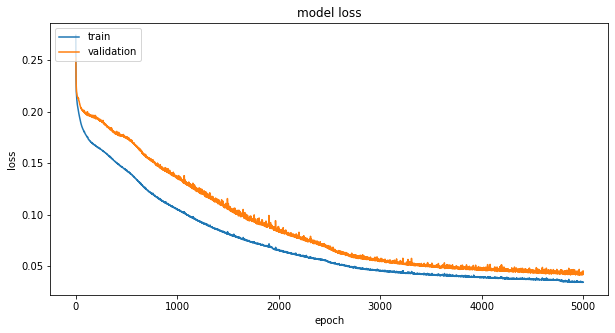

In [29]:
plt.plot(contrastive_history.history['loss'])
plt.plot(contrastive_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

# **Softmax Addition and Post-training**

In [30]:
def classifier_creator(num_classes):
  classifier = Dense(num_classes, activation='softmax', name='classification')

  return classifier

In [31]:
def model_combiner(feature_extractor, classifier):
  feature_extractor_input = feature_extractor.get_layer(index=0).input

  return Model(feature_extractor_input, classifier(feature_extractor(feature_extractor_input)))

In [32]:
lr = 0.001
ep = 1000

classification_layer = classifier_creator(7)
classification_branch = model_combiner(fe, classification_layer)
best_model = SaveBestModel()
opt = optimizers.Adam(learning_rate=lr, decay=lr / ep)
classification_branch.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

history = classification_branch.fit(x_train_scaled, z_train_bin, validation_split=0.25, epochs = ep, callbacks=[best_model])

classification_branch.set_weights(best_model.best_weights)

Epoch 1/1000
9/9 [==============================] - 1s 28ms/step - loss: 2.7704 - accuracy: 0.0189 - val_loss: 2.4328 - val_accuracy: 0.0000e+00
Epoch 2/1000
9/9 [==============================] - 0s 6ms/step - loss: 2.3907 - accuracy: 0.0189 - val_loss: 2.2335 - val_accuracy: 0.0000e+00
Epoch 3/1000
9/9 [==============================] - 0s 7ms/step - loss: 2.2680 - accuracy: 0.0189 - val_loss: 2.1449 - val_accuracy: 0.0114
Epoch 4/1000
9/9 [==============================] - 0s 5ms/step - loss: 2.1905 - accuracy: 0.0833 - val_loss: 2.0718 - val_accuracy: 0.3636
Epoch 5/1000
9/9 [==============================] - 0s 7ms/step - loss: 2.1246 - accuracy: 0.3068 - val_loss: 2.0092 - val_accuracy: 0.3750
Epoch 6/1000
9/9 [==============================] - 0s 5ms/step - loss: 2.0671 - accuracy: 0.3106 - val_loss: 1.9545 - val_accuracy: 0.3750
Epoch 7/1000
9/9 [==============================] - 0s 7ms/step - loss: 2.0140 - accuracy: 0.3106 - val_loss: 1.9048 - val_accuracy: 0.3750
Epoch 8/100

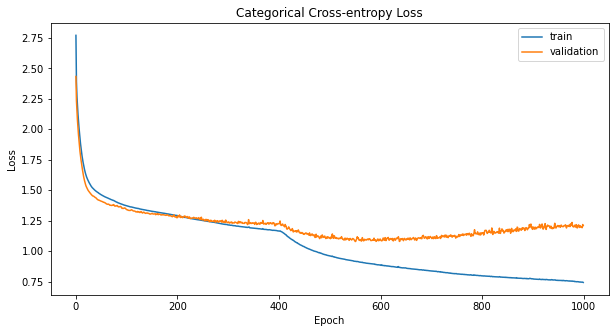

In [33]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Categorical Cross-entropy Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()

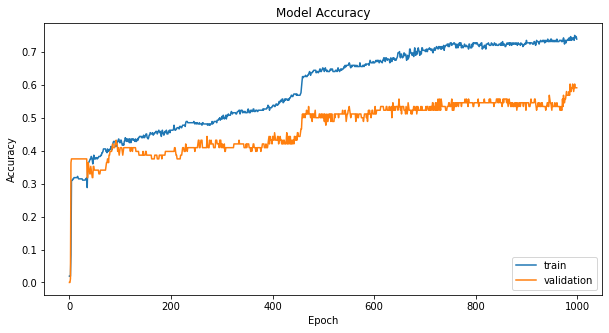

In [34]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='lower right')
plt.show()

In [35]:
accuracies = {
    'train': classification_branch.evaluate(x_train_scaled, z_train_bin)[1],
    'test': classification_branch.evaluate(x_test_scaled, z_test_bin)[1]}

accuracies

4/4 [==============================] - 0s 4ms/step - loss: 1.4615 - accuracy: 0.4407


{'test': 0.4406779706478119, 'train': 0.6306818127632141}

In [36]:
z_train_prob = classification_branch.predict(x_train_scaled)
z_test_prob = classification_branch.predict(x_test_scaled)

# **Training**

In [37]:
x_train_scaled = np.concatenate([x_train_scaled, z_train_prob], axis = 1)
x_train_scaled.shape

(352, 21)

In [38]:
x_test_scaled = np.concatenate([x_test_scaled, z_test_prob], axis = 1)
x_test_scaled.shape

(118, 21)

In [39]:
def model_creator():

  input = Input(shape=21, name='input')
  emb = Dense(units = 16, activation='tanh', name = 'HL1',)(input)
  emb = Dense(units = 11, activation='tanh', name = 'HL2',)(emb)
  # emb = Dense(units = 6, activation='tanh', name = 'HL3',)(emb)
  # emb = Dense(units = 8, activation='tanh', name = 'HL4',)(emb)
  # emb = Dense(units = 8, activation='tanh', name = 'HL5',)(emb)
  predicted_values = Dense(units = 2, activation='tanh', name='values')(emb)

  return Model(inputs = input, outputs = predicted_values)

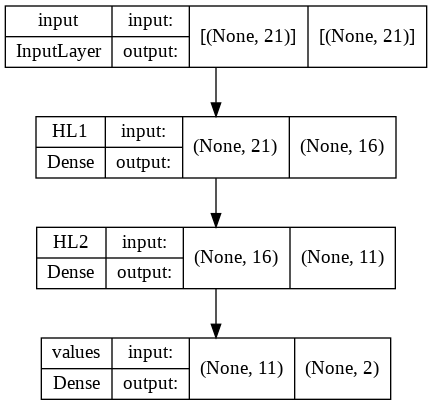

In [40]:
model = model_creator()
plot_model(model, show_shapes = True)

In [41]:
best_model_saver = SaveBestModel('val_loss')

model = model_creator()

lr = 0.001
ep = 1000
opt = optimizers.Adam(learning_rate=lr, decay=lr / ep)

model.compile(loss = 'mse', optimizer=opt)

history  = model.fit(x = x_train_scaled, y = y_train_scaled,
                     validation_split = 0.25, epochs = ep, callbacks=[best_model_saver])

model.set_weights(best_model_saver.best_weights)

Epoch 1/1000
9/9 [==============================] - 1s 21ms/step - loss: 0.5318 - val_loss: 0.3993
Epoch 2/1000
9/9 [==============================] - 0s 7ms/step - loss: 0.3478 - val_loss: 0.2494
Epoch 3/1000
9/9 [==============================] - 0s 5ms/step - loss: 0.2235 - val_loss: 0.1602
Epoch 4/1000
9/9 [==============================] - 0s 7ms/step - loss: 0.1567 - val_loss: 0.1173
Epoch 5/1000
9/9 [==============================] - 0s 5ms/step - loss: 0.1262 - val_loss: 0.1024
Epoch 6/1000
9/9 [==============================] - 0s 7ms/step - loss: 0.1165 - val_loss: 0.0968
Epoch 7/1000
9/9 [==============================] - 0s 7ms/step - loss: 0.1124 - val_loss: 0.0936
Epoch 8/1000
9/9 [==============================] - 0s 7ms/step - loss: 0.1091 - val_loss: 0.0906
Epoch 9/1000
9/9 [==============================] - 0s 5ms/step - loss: 0.1056 - val_loss: 0.0885
Epoch 10/1000
9/9 [==============================] - 0s 7ms/step - loss: 0.1023 - val_loss: 0.0862
Epoch 11/1000
9/9 

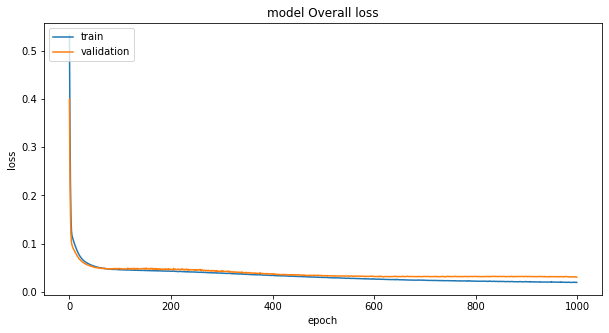

In [42]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model Overall loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

# **Model Evaluation**

In [46]:
y_train_pred = model.predict(x_train_scaled)
y_test_pred = model.predict(x_test_scaled)

# z_train_pred = model.predict(x_train_scaled)[1]
# z_test_pred = model.predict(x_test_scaled)[1]


## Regression

### MSE Loss

In [47]:
from sklearn.metrics import mean_squared_error

mse_losses = {
    'train': mean_squared_error(y_train_pred, y_train_scaled),
    'test': mean_squared_error(y_test_pred, y_test_scaled)}

mse_losses

{'test': 0.048328470126203935, 'train': 0.022029522410684815}

### MAE Loss

In [48]:
from sklearn.metrics import mean_absolute_error
mae_losses_both = {
    'train': mean_absolute_error(y_train_pred, y_train_scaled),
    'test': mean_absolute_error(y_test_pred, y_test_scaled)}

mae_losses_both

{'test': 0.14573975689238544, 'train': 0.09788348536862963}

In [49]:
mae_losses_health_index = {
    'train': mean_absolute_error(y_train_pred[:, 0], y_train_scaled[:, 0]),
    'test': mean_absolute_error(y_test_pred[:, 0], y_test_scaled[:, 0])}

mae_losses_health_index

{'test': 0.10986819204075123, 'train': 0.08974772999671118}

In [50]:
mae_losses_life_expectation = {
    'train': mean_absolute_error(y_train_pred[:, 1], y_train_scaled[:, 1]),
    'test': mean_absolute_error(y_test_pred[:, 1], y_test_scaled[:, 1])}

mae_losses_life_expectation

{'test': 0.18161132174401973, 'train': 0.1060192407405482}